# EDA: Beauty & Clothing Cross-Category Transfer Potential

In [5]:
import pandas as pd
import json
import gzip
import numpy as np
from typing import Any
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

In [6]:
# --- Config ---
TARGET_CATEGORY: str = "Beauty_and_Personal_Care"
SOURCE_CATEGORY: str = "Clothing_Shoes_and_Jewelry"
CAT_NAMES: dict[str, str] = {
    "Beauty_and_Personal_Care": "Beauty",
    "Clothing_Shoes_and_Jewelry": "Clothing",
}
DATA_DIR: str = "../data"
RANDOM_SEED: int = 67

# Only include reviews that satisfy all of the following criteria
START_DATE: str | None = "2021-01-01"
END_DATE: str | None = "2022-12-31"
MIN_RATING: int | None = None

# Data split cutoff dates
TRAIN_END_CUTOFF_DATE: str = "2022-08-01"
VALID_END_CUTOFF_DATE: str = "2022-10-01"

# Review count thresholds 
USER_MIN_REVIEWS: int = 5
WARM_USER_MIN_REVIEWS: int = 10
WARM_ITEM_MIN_REVIEWS: int = 5
MIN_CLOTHING_TRAIN_REVIEWS: int = 3

COLORS: dict[str, str] = {
    "Beauty_and_Personal_Care": "#e91e8c",
    "Clothing_Shoes_and_Jewelry": "#3f51b5",
}

In [7]:
def stream_jsonl(path: str, fields: list[str] | None = None):
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for _, line in enumerate(f):
            obj = json.loads(line)
            if fields is not None:
                obj = {k: obj.get(k) for k in fields}
            yield obj

def _date_to_ms(date_str: str | None) -> int | None:
    if date_str is None:
        return None
    return int(pd.Timestamp(date_str, tz="UTC").timestamp() * 1000)

def load_reviews(
    categories: list[str],
    start_date: str | None = None, end_date: str | None = None,
    min_rating: int | None = None
) -> list[dict[str, Any]]:
    start_ts = _date_to_ms(start_date)
    end_ts = _date_to_ms(end_date)
    print(f"Filtering: start_date={start_date}, end_date={end_date}, min_rating={min_rating}")

    reviews: list[dict[str, Any]] = []
    for cat in categories:
        path = f"{DATA_DIR}/{cat}.jsonl.gz"
        print(f"Loading: {path}")
        for obj in stream_jsonl(path, fields=[
            'user_id', 'parent_asin', 'rating', 'timestamp'
        ]):
            ts: Any = obj.get("timestamp")
            rating: Any = obj.get("rating")
            if start_ts is not None and (ts is not None and ts < start_ts):
                continue
            if end_ts is not None and (ts is not None and ts > end_ts):
                continue
            if min_rating is not None and (rating is not None and rating < min_rating):
                continue
            obj["category"] = cat
            reviews.append(obj)
    return reviews

## Data loading



In [8]:
reviews = load_reviews(
    [TARGET_CATEGORY, SOURCE_CATEGORY], start_date=START_DATE, end_date=END_DATE,
    min_rating=MIN_RATING
)
print(f"Loaded {len(reviews):,} reviews total")

df_reviews = pd.DataFrame(reviews)
display(df_reviews.head())
df_reviews.info()

del reviews  # free memory after creating DataFrame

Filtering: start_date=2021-01-01, end_date=2022-12-31, min_rating=None
Loading: ../data/Beauty_and_Personal_Care.jsonl.gz
Loading: ../data/Clothing_Shoes_and_Jewelry.jsonl.gz
Loaded 27,220,447 reviews total


,user_id,parent_asin,rating,timestamp,category
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B00Z03RC80,1.0,1616743454733,Beauty_and_Personal_Care
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B085PRT2MP,1.0,1614915977684,Beauty_and_Personal_Care
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B08G81QQ9L,5.0,1612052493701,Beauty_and_Personal_Care
3,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07YYG76X1,1.0,1609700981786,Beauty_and_Personal_Care
4,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,B00C5AHTAC,5.0,1671844437231,Beauty_and_Personal_Care


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27220447 entries, 0 to 27220446
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   user_id      object 
 1   parent_asin  object 
 2   rating       float64
 3   timestamp    int64  
 4   category     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.0+ GB


## Deduplicate reviews 

In [9]:
# Remove duplicate (user_id, parent_asin) pairs, keeping the most recent review.
before = len(df_reviews)
df_reviews = df_reviews.sort_values("timestamp").drop_duplicates(
    subset=["user_id", "parent_asin"], keep="last"
)
df_reviews = df_reviews.reset_index(drop=True)
after = len(df_reviews)
print(f"Removed {before - after:,} duplicate (user_id, parent_asin) reviews ({after:,} unique pairs remain)")

Removed 343,836 duplicate (user_id, parent_asin) reviews (26,876,611 unique pairs remain)


## Filter min user reviews

In [10]:
# Filter users with fewer than USER_MIN_REVIEWS reviews in the target category
before_users = df_reviews["user_id"].nunique()
before_reviews = len(df_reviews)
target_mask = df_reviews["category"] == TARGET_CATEGORY
user_counts = df_reviews[target_mask].groupby("user_id").size()
valid_users = user_counts[user_counts >= USER_MIN_REVIEWS].index
df_reviews = df_reviews[df_reviews["user_id"].isin(valid_users)]
after_users = df_reviews["user_id"].nunique()
after_reviews = len(df_reviews)
removed_users = before_users - after_users
removed_reviews = before_reviews - after_reviews
print(f"Removed {removed_users:,} users with < {USER_MIN_REVIEWS} target-category reviews "
      f"({after_users:,} users remain, {removed_reviews:,} reviews removed)")

Removed 11,531,872 users with < 5 target-category reviews (168,377 users remain, 23,911,061 reviews removed)


## Split train/valid/test with cutoff timestamps

In [11]:
train_end_ts = _date_to_ms(TRAIN_END_CUTOFF_DATE)
valid_end_ts = _date_to_ms(VALID_END_CUTOFF_DATE)
print(f"Train end timestamp: {train_end_ts} ({pd.Timestamp(train_end_ts, unit='ms', tz='UTC')})")
print(f"Valid end timestamp: {valid_end_ts} ({pd.Timestamp(valid_end_ts, unit='ms', tz='UTC')})")

Train end timestamp: 1659312000000 (2022-08-01 00:00:00+00:00)
Valid end timestamp: 1664582400000 (2022-10-01 00:00:00+00:00)


In [12]:
# Split beauty by time (matching preprocessing logic)
df_beauty = df_reviews[df_reviews["category"] == TARGET_CATEGORY]
df_beauty_train = df_beauty[df_beauty["timestamp"] <= train_end_ts]
beauty_train_user_ids = set(df_beauty_train["user_id"].unique())
# All clothing reviews from beauty-train users (no time filter, matching preprocessing)
df_clothing = df_reviews[
    (df_reviews["category"] == SOURCE_CATEGORY)
    & (df_reviews["user_id"].isin(beauty_train_user_ids))
]
df_reviews_train = pd.concat([df_beauty_train, df_clothing], ignore_index=True)

## Filter min item reviews

In [13]:
# --- Clothing item tail analysis ---
clothing_train = df_clothing
clothing_counts = clothing_train.groupby("parent_asin").size()
clothing_items_total = len(clothing_counts)
clothing_inters_total = len(clothing_train)

print("=== Clothing item train review frequency ===")
for k in [1, 2, 3, 4, 5, 10]:
    n = (clothing_counts == k).sum() if k <= 4 else (clothing_counts >= k).sum()
    label = f"{'=' if k <= 4 else '>='} {k}"
    print(f"  {label:>4} reviews: {n:>6,} items ({n/clothing_items_total*100:5.1f}%)")

print()
print(f"Impact of filtering at >= {MIN_CLOTHING_TRAIN_REVIEWS} reviews:")
n_removed = (clothing_counts < MIN_CLOTHING_TRAIN_REVIEWS).sum()
removed_inters = clothing_counts[clothing_counts < MIN_CLOTHING_TRAIN_REVIEWS].sum()
print(f"  Clothing items removed:   {n_removed:>6,} ({n_removed/clothing_items_total*100:.1f}%)")
print(f"  Clothing inters removed:  {removed_inters:>6,} ({removed_inters/clothing_inters_total*100:.1f}%)")
print(f"  Clothing items remaining: {clothing_items_total - n_removed:>6,}")


=== Clothing item train review frequency ===
   = 1 reviews: 275,803 items ( 63.4%)
   = 2 reviews: 57,224 items ( 13.2%)
   = 3 reviews: 26,952 items (  6.2%)
   = 4 reviews: 16,595 items (  3.8%)
  >= 5 reviews: 58,458 items ( 13.4%)
  >= 10 reviews: 22,565 items (  5.2%)

Impact of filtering at >= 3 reviews:
  Clothing items removed:   333,027 (76.6%)
  Clothing inters removed:  390,251 (30.8%)
  Clothing items remaining: 102,005


In [14]:
# --- Filter: drop clothing items with < MIN_CLOTHING_TRAIN_REVIEWS train reviews ---
clothing_mask = df_reviews_train["category"] == SOURCE_CATEGORY
clothing_iid_counts = df_reviews_train[clothing_mask].groupby("parent_asin").size()
valid_clothing_iids = set(clothing_iid_counts[clothing_iid_counts >= MIN_CLOTHING_TRAIN_REVIEWS].index)
df_reviews_train = df_reviews_train[~clothing_mask | df_reviews_train["parent_asin"].isin(valid_clothing_iids)]
n_before = len(clothing_iid_counts)
n_after = df_reviews_train[clothing_mask]["parent_asin"].nunique()
print(f"Filtered clothing items: {n_before:,} -> {n_after:,} "
      f"(removed {n_before - n_after:,} with < {MIN_CLOTHING_TRAIN_REVIEWS} train reviews)")

train_users = set(beauty_train_user_ids)

/var/folders/vm/77wrgjgj5wzbyghx353b7gym0000gn/T/ipykernel_17470/1911994912.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  n_after = df_reviews_train[clothing_mask]["parent_asin"].nunique()


Filtered clothing items: 435,032 -> 102,005 (removed 333,027 with < 3 train reviews)


## Beauty vs. Clothing reviews overlap

In [15]:
user_sets = {
    cat: set(df_reviews[df_reviews["category"] == cat]["user_id"].unique())
    for cat in CAT_NAMES.keys()
}

beauty_users = user_sets[TARGET_CATEGORY]
clothing_users = user_sets[SOURCE_CATEGORY]
overlap = beauty_users & clothing_users

print(f"% of Beauty users also in Clothing: {100 * len(overlap) / max(len(beauty_users), 1):.2f}%")
print(f"Users in both categories:  {len(overlap):>10,}")
print(f"Beauty-only users:        {len(beauty_users - clothing_users):>10,}")

% of Beauty users also in Clothing: 85.37%
Users in both categories:     143,736
Beauty-only users:            24,641


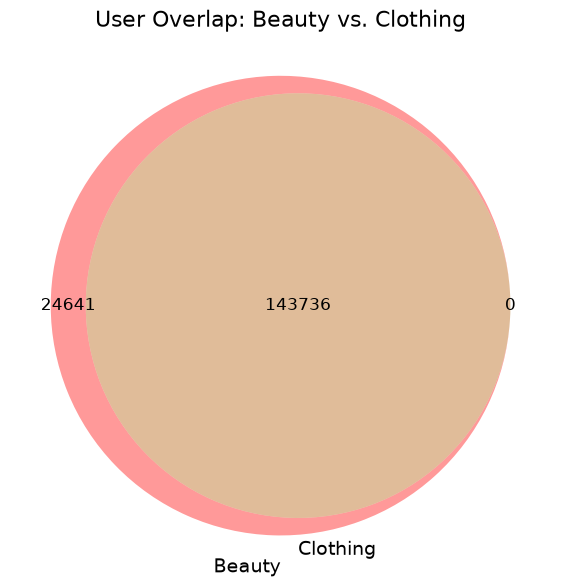

In [16]:
# Venn diagram: user overlap between Beauty and Clothing
fig, ax = plt.subplots(figsize=(8, 6))
v = venn2(
    subsets=(
        len(beauty_users - clothing_users),
        len(clothing_users - beauty_users),
        len(beauty_users & clothing_users),
    ),
    set_labels=("Beauty", "Clothing"),
    ax=ax,
)
for text in v.subset_labels:
    if text:
        text.set_fontsize(12)
for text in v.set_labels:
    text.set_fontsize(14)
ax.set_title("User Overlap: Beauty vs. Clothing", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
def compute_density_metrics(df_train: pd.DataFrame) -> dict[str, float]:
    n_users = len(set(df_train["user_id"].unique()))
    n_items = len(set(df_train["parent_asin"].unique()))
    n_interactions = len(df_train)

    interactions_per_user = n_interactions / max(n_users, 1)
    sparsity = 1 - n_interactions / (n_users * n_items) if n_users * n_items > 0 else 1.0

    return {
        "Train interactions": n_interactions,
        "Train items": n_items,
        "Interactions/user": interactions_per_user,
        "Sparsity (train)": sparsity,
    }

beauty_metrics = compute_density_metrics(
    df_reviews_train[df_reviews_train["category"] == TARGET_CATEGORY]
)
combined_metrics = compute_density_metrics(df_reviews_train)

rows = []
for metric in beauty_metrics:
    b, c = beauty_metrics[metric], combined_metrics[metric]
    rows.append({
        "Dataset": metric,
        "Beauty-only": f"{b}" if metric != "Sparsity (train)" else f"{b:.6f}",
        "Beauty+Clothing": f"{c}" if metric != "Sparsity (train)" else f"{c:.6f}",
        "Change": f"{(c - b) / b * 100:+.1f}%" if b != 0 else "—"
    })

pd.DataFrame(rows)

,Dataset,Beauty-only,Beauty+Clothing,Change
0,Train interactions,1125023,2001046,+77.9%
1,Train items,215358,317363,+47.4%
2,Interactions/user,7.18924255688971,12.787298625444926,+77.9%
3,Sparsity (train),0.999967,0.999960,-0.0%


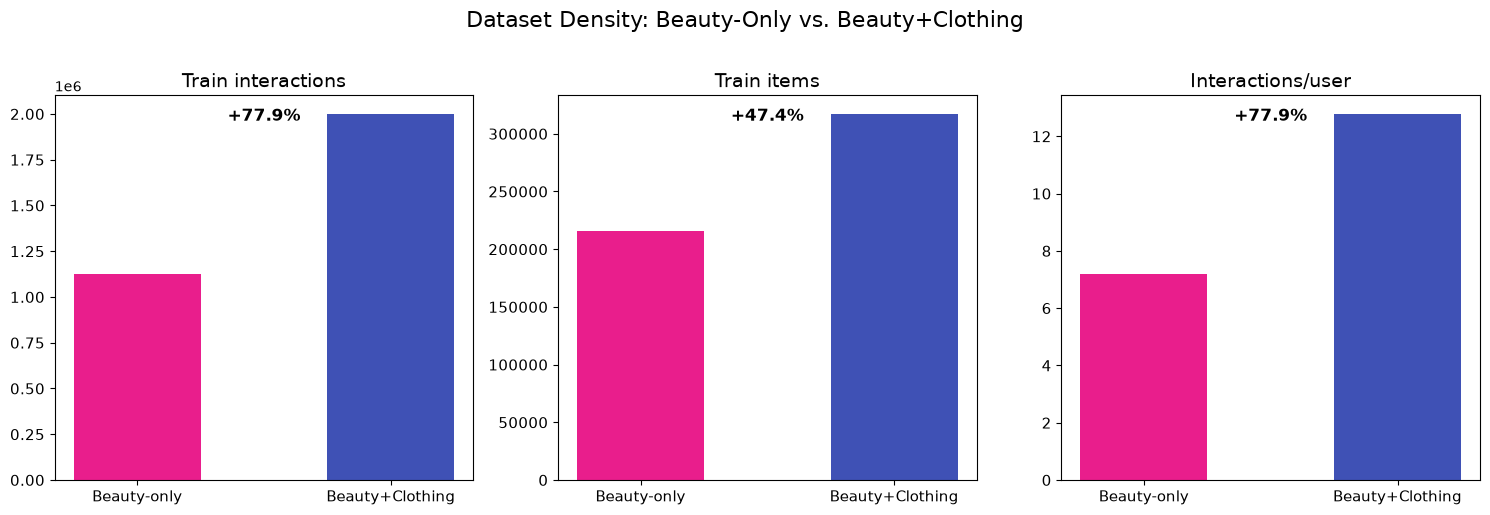

In [18]:
# Grouped bar chart: beauty-only vs combined
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metric_names = ["Train interactions", "Train items", "Interactions/user"]
metric_keys = ["Train interactions", "Train items", "Interactions/user"]
colors = ["#e91e8c", "#3f51b5"]

for i, (ax, name, key) in enumerate(zip(axes, metric_names, metric_keys)):
    b = beauty_metrics[key]
    c = combined_metrics[key]
    ax.bar(["Beauty-only", "Beauty+Clothing"], [b, c], color=colors, width=0.5)
    ax.set_title(name, fontsize=14)
    ax.tick_params(labelsize=11)
    pct = f"{(c - b) / b * 100:+.1f}%" if b else ""
    ax.annotate(pct, xy=(0.5, c), fontsize=12, ha="center",
                xytext=(0, -5), textcoords="offset points", fontweight="bold")

plt.suptitle("Dataset Density: Beauty-Only vs. Beauty+Clothing", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Beauty vs. Clothing ratings & review count correlation

Do users behave consistently across categories? Modest positive rating correlation hints at shared rating patterns across domains.

In [19]:
avg_ratings = {}
for cat in [TARGET_CATEGORY, SOURCE_CATEGORY]:
    name = CAT_NAMES[cat]
    avg_ratings[name] = (
        df_reviews[df_reviews["category"] == cat]
        .groupby("user_id")["rating"]
        .mean()
        .rename(f"avg_{name}")
    )

rating_profile = pd.concat(avg_ratings.values(), axis=1).dropna()
rating_r = rating_profile.iloc[:, 0].corr(rating_profile.iloc[:, 1])
print(f"Users with ratings in both categories: {len(rating_profile):,}")
print(f"Rating correlation (Beauty vs Clothing): r = {rating_r:.4f}")

Users with ratings in both categories: 143,736
Rating correlation (Beauty vs Clothing): r = 0.4532


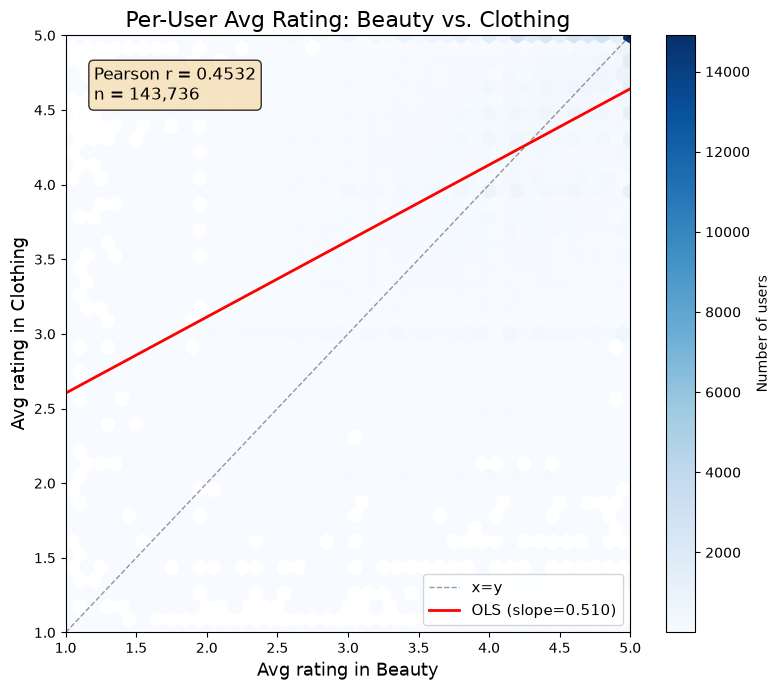

In [20]:
# Hexbin scatter: average rating per user (Beauty vs Clothing)
fig, ax = plt.subplots(figsize=(8, 7))

hb = ax.hexbin(
    rating_profile["avg_Beauty"], rating_profile["avg_Clothing"],
    gridsize=40, cmap="Blues", mincnt=1, linewidths=0.2,
)
cb = fig.colorbar(hb, ax=ax, label="Number of users")

# Diagonal x=y
lims = [1, 5]
ax.plot(lims, lims, "k--", alpha=0.4, linewidth=1, label="x=y")

# Regression line
from numpy.polynomial.polynomial import polyfit
coefs = polyfit(rating_profile["avg_Beauty"], rating_profile["avg_Clothing"], 1)
x_line = np.linspace(1, 5, 100)
ax.plot(x_line, coefs[0] + coefs[1] * x_line, "r-", linewidth=2, label=f"OLS (slope={coefs[1]:.3f})")

ax.set_xlim(1, 5)
ax.set_ylim(1, 5)
ax.set_xlabel("Avg rating in Beauty", fontsize=13)
ax.set_ylabel("Avg rating in Clothing", fontsize=13)
ax.set_title("Per-User Avg Rating: Beauty vs. Clothing", fontsize=16)
ax.legend(fontsize=11)
ax.text(0.05, 0.95, f"Pearson r = {rating_r:.4f}\nn = {len(rating_profile):,}",
        transform=ax.transAxes, fontsize=12, va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
plt.tight_layout()
plt.show()

In [21]:
beauty_activity = df_reviews[df_reviews["category"] == TARGET_CATEGORY].groupby("user_id").size().rename("beauty_count")
clothing_activity = df_reviews[df_reviews["category"] == SOURCE_CATEGORY].groupby("user_id").size().rename("clothing_count")

user_profile = (
    beauty_activity.to_frame()
    .join(clothing_activity, how="outer")
    .fillna(0)
    .astype(int)
)
overlap_profile = user_profile[
    (user_profile["beauty_count"] > 0) & (user_profile["clothing_count"] > 0)
].copy()

act_r_raw = overlap_profile["beauty_count"].corr(overlap_profile["clothing_count"])
print(f"Users active in both categories: {len(overlap_profile):,}")
print(f"Activity correlation (raw):       r = {act_r_raw:.4f}")

Users active in both categories: 143,736
Activity correlation (raw):       r = 0.3254


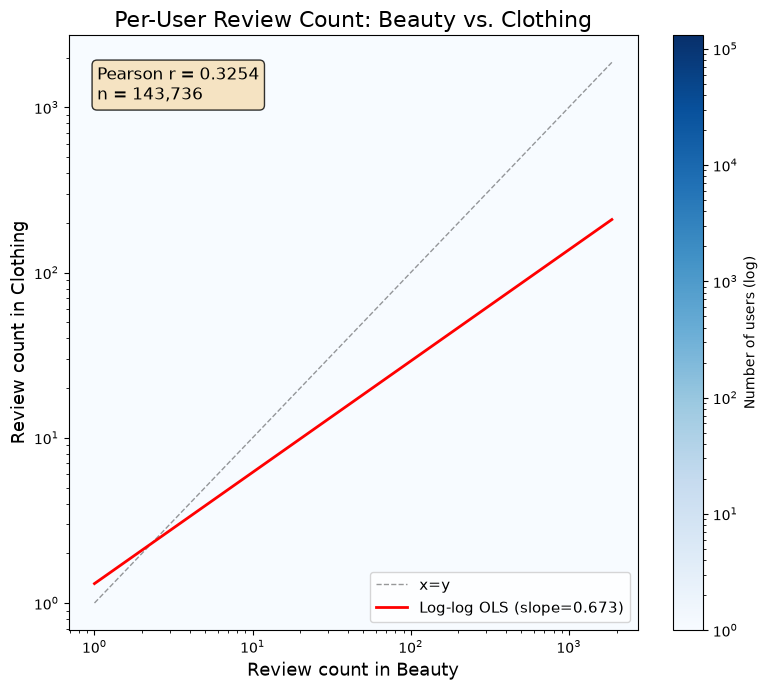

In [22]:
# Hexbin scatter: review count per user (Beauty vs Clothing)
import numpy as np

fig, ax = plt.subplots(figsize=(8, 7))

hb = ax.hexbin(
    overlap_profile["beauty_count"], overlap_profile["clothing_count"],
    gridsize=40, cmap="Blues", mincnt=1, linewidths=0.2, bins="log",
)
cb = fig.colorbar(hb, ax=ax, label="Number of users (log)")

# Diagonal x=y
max_val = max(
    overlap_profile["beauty_count"].max(),
    overlap_profile["clothing_count"].max(),
)
ax.plot([1, max_val], [1, max_val], "k--", alpha=0.4, linewidth=1, label="x=y")

# Regression on log-log
log_b = np.log10(overlap_profile["beauty_count"].values)
log_c = np.log10(overlap_profile["clothing_count"].values)
coefs = polyfit(log_b, log_c, 1)
x_line = np.logspace(0, np.log10(max_val), 100)
ax.plot(x_line, 10 ** (coefs[0] + coefs[1] * np.log10(x_line)),
        "r-", linewidth=2, label=f"Log-log OLS (slope={coefs[1]:.3f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Review count in Beauty", fontsize=13)
ax.set_ylabel("Review count in Clothing", fontsize=13)
ax.set_title("Per-User Review Count: Beauty vs. Clothing", fontsize=16)
ax.legend(fontsize=11)
ax.text(0.05, 0.95, f"Pearson r = {act_r_raw:.4f}\nn = {len(overlap_profile):,}",
        transform=ax.transAxes, fontsize=12, va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
plt.tight_layout()
plt.show()

## Explore train data

In [23]:
# Warm/cold based on beauty train reviews only (matching preprocessing)
beauty_train_counts = df_beauty_train.groupby("user_id").size()
cold_user_ids: set[str] = set(beauty_train_counts[beauty_train_counts < WARM_USER_MIN_REVIEWS].index)
warm_user_ids: set[str] = set(beauty_train_counts[beauty_train_counts >= WARM_USER_MIN_REVIEWS].index)
print(f"Warm users (>= {WARM_USER_MIN_REVIEWS} beauty train reviews): {len(warm_user_ids):,}")
print(f"Cold users (< {WARM_USER_MIN_REVIEWS} beauty train reviews): {len(cold_user_ids):,}")

Warm users (>= 10 beauty train reviews): 20,100
Cold users (< 10 beauty train reviews): 136,387


In [24]:
# Warm/cold items based on all train reviews (matching preprocessing)
train_item_counts = df_reviews_train.groupby("parent_asin").size().reset_index(name="num_train")
warm_item_ids_full = set(train_item_counts[train_item_counts["num_train"] >= WARM_ITEM_MIN_REVIEWS]["parent_asin"])
cold_item_ids_full = set(train_item_counts[train_item_counts["num_train"] < WARM_ITEM_MIN_REVIEWS]["parent_asin"])
total = len(warm_item_ids_full) + len(cold_item_ids_full)
print(f"Warm items (>= {WARM_ITEM_MIN_REVIEWS} train reviews): {len(warm_item_ids_full):,}")
print(f"Cold items (< {WARM_ITEM_MIN_REVIEWS} train reviews): {len(cold_item_ids_full):,}")

Warm items (>= 5 train reviews): 108,941
Cold items (< 5 train reviews): 208,422


In [25]:
train_item_ids = set(df_reviews_train["parent_asin"].unique())
print(f"Train items: {len(train_item_ids):,}")

Train items: 317,363


In [26]:
def analyze_user_segment(split_name: str, df: pd.DataFrame):
    all_users = set(df["user_id"].unique())
    n_users = len(all_users)

    all_items = set(df["parent_asin"].unique())
    n_items = len(all_items)
    warm_i = len(all_items & warm_item_ids_full)
    cold_i = n_items - warm_i

    # Category breakdown — users
    beauty_u = set(df[df["category"] == TARGET_CATEGORY]["user_id"].unique())
    clothing_u = set(df[df["category"] == SOURCE_CATEGORY]["user_id"].unique())
    b_only = beauty_u - clothing_u
    c_only = clothing_u - beauty_u
    both = beauty_u & clothing_u

    # Category breakdown — items
    beauty_i = set(df[df["category"] == TARGET_CATEGORY]["parent_asin"].unique())
    clothing_i = set(df[df["category"] == SOURCE_CATEGORY]["parent_asin"].unique())

    # Category breakdown — interactions
    n_beauty_inter = len(df[df["category"] == TARGET_CATEGORY])
    n_clothing_inter = len(df[df["category"] == SOURCE_CATEGORY])
    n_inter = n_beauty_inter + n_clothing_inter

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    warm_colors = ["#4CAF50", "#FF9800"]
    cat_colors = ["#e91e8c", "#9c27b0", "#3f51b5"]
    explode = (0.03, 0.03)

    # (0, 0): Users by category
    axes[0, 0].pie(
        [len(b_only), len(both), len(c_only)],
        labels=[f"Beauty-only\n({len(b_only):,})", f"Both\n({len(both):,})", f"Clothing-only\n({len(c_only):,})"],
        autopct="%1.1f%%", colors=cat_colors, startangle=90,
        explode=(0.03, 0.03, 0.03), textprops={"fontsize": 13},
    )
    axes[0, 0].set_title(f"Users by Category (n={n_users:,})", fontsize=16)

    # (0, 1): Interactions by category
    axes[0, 1].pie(
        [n_beauty_inter, n_clothing_inter],
        labels=[f"Beauty\n({n_beauty_inter:,})", f"Clothing\n({n_clothing_inter:,})"],
        autopct="%1.1f%%", colors=[cat_colors[0], cat_colors[2]],
        startangle=90, explode=explode, textprops={"fontsize": 14},
    )
    axes[0, 1].set_title(f"Interactions by Category (n={n_inter:,})", fontsize=16)

    # (1, 0): Items by warmth
    axes[1, 0].pie([warm_i, cold_i], labels=["Warm", "Cold"], autopct="%1.1f%%",
                   colors=warm_colors, startangle=90, explode=explode,
                   textprops={"fontsize": 14})
    axes[1, 0].set_title(f"Items by Warm/Cold (n={n_items:,})", fontsize=16)

    # (1, 1): Items by category
    axes[1, 1].pie(
        [len(beauty_i), len(clothing_i)],
        labels=[f"Beauty\n({len(beauty_i):,})", f"Clothing\n({len(clothing_i):,})"],
        autopct="%1.1f%%", colors=[cat_colors[0], cat_colors[2]],
        startangle=90, explode=explode, textprops={"fontsize": 14},
    )
    axes[1, 1].set_title(f"Items by Category (n={n_items:,})", fontsize=16)

    plt.tight_layout()
    plt.show()

    # Summary
    def _pct(v: int, t: int) -> str:
        return f"{v / t * 100:.1f}%" if t else "-"

    print(f"{'=' * 55}")
    print(f"  {split_name} Set \u2014 Summary")
    print(f"{'=' * 55}")
    print(f"  Users: {n_users:,}  |  Items: {n_items:,}  |  Interactions: {n_inter:,}")
    print(f"  Beauty-only users: {len(b_only):,} ({_pct(len(b_only), n_users)})  |  "
          f"Both: {len(both):,} ({_pct(len(both), n_users)})  |  "
          f"Clothing-only: {len(c_only):,} ({_pct(len(c_only), n_users)})")
    print(f"  Beauty interactions: {n_beauty_inter:,} ({_pct(n_beauty_inter, n_inter)})  |  "
          f"Clothing interactions: {n_clothing_inter:,} ({_pct(n_clothing_inter, n_inter)})")
    print(f"  Beauty items: {len(beauty_i):,} ({_pct(len(beauty_i), n_items)})  |  "
          f"Clothing items: {len(clothing_i):,} ({_pct(len(clothing_i), n_items)})")
    print(f"  Warm items: {warm_i:,} ({_pct(warm_i, n_items)})  |  "
          f"Cold items: {cold_i:,} ({_pct(cold_i, n_items)})")

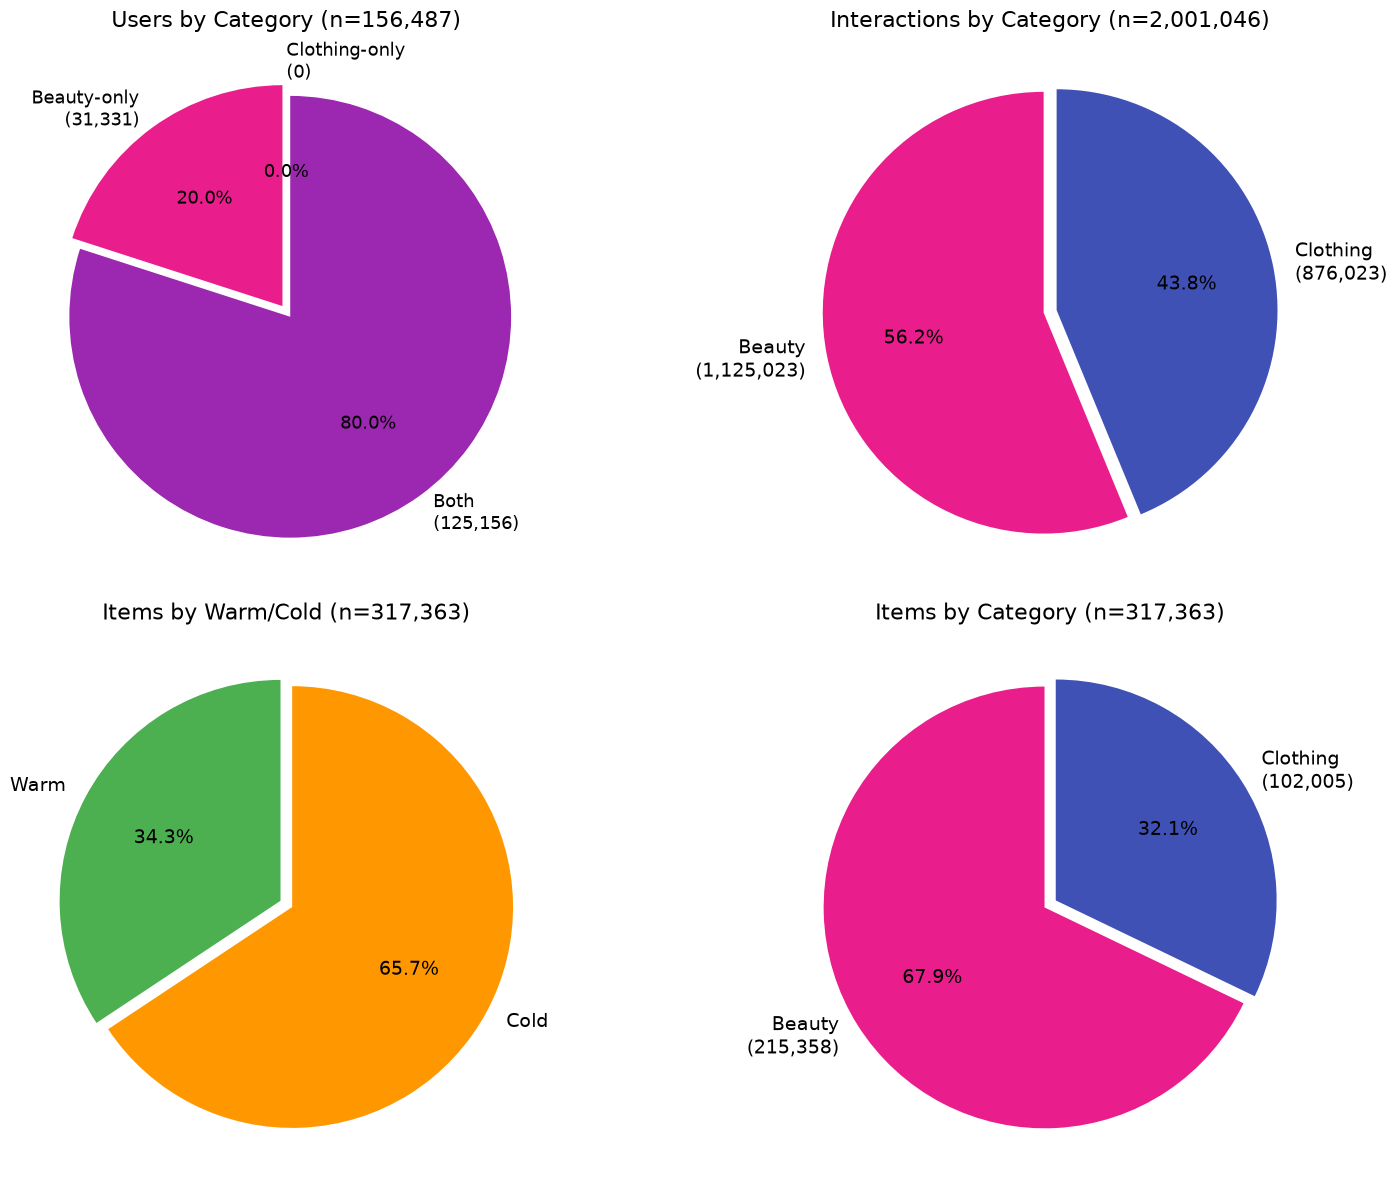

  Train Set — Summary
  Users: 156,487  |  Items: 317,363  |  Interactions: 2,001,046
  Beauty-only users: 31,331 (20.0%)  |  Both: 125,156 (80.0%)  |  Clothing-only: 0 (0.0%)
  Beauty interactions: 1,125,023 (56.2%)  |  Clothing interactions: 876,023 (43.8%)
  Beauty items: 215,358 (67.9%)  |  Clothing items: 102,005 (32.1%)
  Warm items: 108,941 (34.3%)  |  Cold items: 208,422 (65.7%)


In [27]:
analyze_user_segment("Train", df_reviews_train)